合并两组数据，结合品牌标签和用户正向情感得分进行用户偏好分析和竞品分析：

1.各品牌×各Topic 平均正面得分热力图	各品牌在4个Topic上做得怎么样？（能力评估）

2.各品牌×各Topic 提及频率热力图	各品牌用户在意哪个Topic？（关注点评估）

3.各品牌四象限分析图	结合得分和关注度，得出各品牌的痛点区，优势区，高优区，机会区和各自合适的营销策略。

Combine two datasets, integrating brand labels and user positive sentiment scores to conduct user preference analysis:

Heatmap of Average Positive Score by Brand × Topic
How well does each brand perform on the four topics? (Capability assessment)

Heatmap of Mention Frequency by Brand × Topic
Which topics do users of each brand care about most? (Attention assessment)

Four-Quadrant Analysis Chart by Brand
By combining scores and attention levels, identify for each brand:

Pain point zones

Advantage zones

High-priority zones

Opportunity zones
And derive appropriate marketing strategies for each zone.


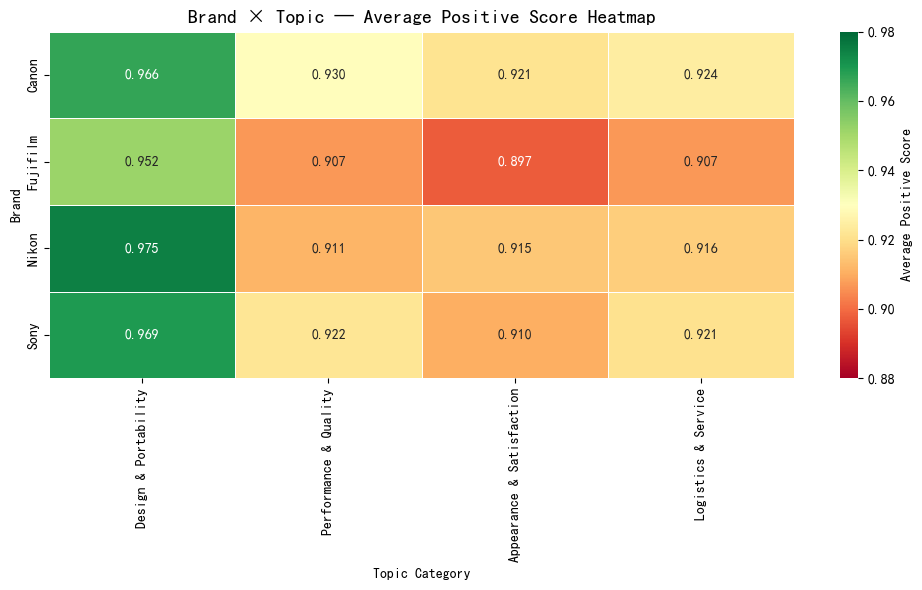

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('camera_sentiment_label.xlsx')
df = df.dropna(subset=['topic_label'])

# 保持中文品牌名用于数据筛选
brands_cn = ['佳能', '富士', '尼康', '索尼']
df = df[df['品牌'].isin(brands_cn)]

topic_order = ['Design & Portability', 'Performance & Quality', 'Appearance & Satisfaction', 'Logistics & Service']
df['topic_label'] = pd.Categorical(df['topic_label'], categories=topic_order, ordered=True)

# 计算数据（使用中文品牌名）
heatmap_data = df.groupby(['品牌', 'topic_label'])['positive_score'].mean().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(brands_cn)

# 将索引（品牌）从中文改为英文用于显示
brands_en = ['Canon', 'Fujifilm', 'Nikon', 'Sony']
heatmap_data.index = brands_en

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0.88, vmax=0.98, linewidths=0.5, cbar_kws={'label': 'Average Positive Score'})
plt.title('Brand × Topic — Average Positive Score Heatmap', fontsize=14)
plt.xlabel('Topic Category')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig('heatmap_positive_score_by_topic.png', dpi=300)
plt.show()

横向比较（看同一行） 比较对象：同一个品牌，不同Topic之间比

横向分析（看同一列） 在某个具体方面，哪个品牌做得最好？哪个最差？

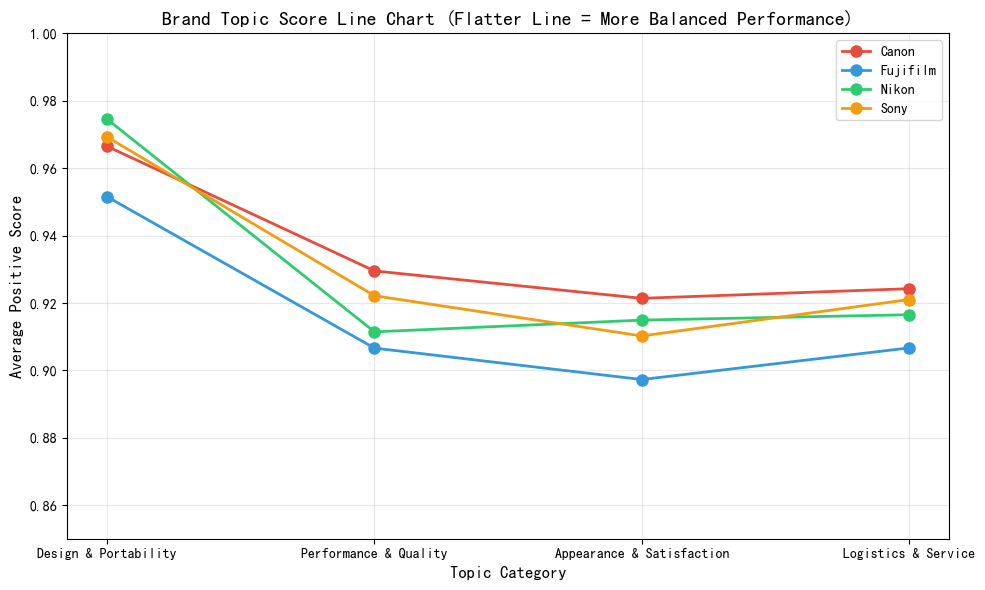

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('camera_sentiment_label.xlsx')
df = df.dropna(subset=['topic_label'])

# 数据筛选使用中文品牌名
brands_cn = ['佳能', '富士', '尼康', '索尼']
df = df[df['品牌'].isin(brands_cn)]

topic_order = ['Design & Portability', 'Performance & Quality', 'Appearance & Satisfaction', 'Logistics & Service']
df['topic_label'] = pd.Categorical(df['topic_label'], categories=topic_order, ordered=True)

brand_topic_score = df.groupby(['品牌', 'topic_label'])['positive_score'].mean().unstack()
brand_topic_score = brand_topic_score.reindex(brands_cn)
brand_topic_score = brand_topic_score[topic_order]

# 将索引（品牌）从中文改为英文用于显示
brands_en = ['Canon', 'Fujifilm', 'Nikon', 'Sony']
brand_topic_score.index = brands_en

# 绘图
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, brand in enumerate(brands_en):
    plt.plot(topic_order, brand_topic_score.loc[brand], 'o-', 
             color=colors[i], linewidth=2, markersize=8, label=brand)

plt.xlabel('Topic Category', fontsize=12)  # 英文
plt.ylabel('Average Positive Score', fontsize=12)  # 英文
plt.title('Brand Topic Score Line Chart (Flatter Line = More Balanced Performance)', fontsize=14)  # 英文
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('balanced_line_chart.png', dpi=300)  # 英文文件名
plt.show()

由以上两图得出结论：
佳能、尼康、索尼三个品牌得分接近（0.91-0.98），构成第一梯队；富士在所有维度上均明显落后（0.89-0.91），独自构成第二梯队，与第一梯队差距略大。
第一梯队（佳能、尼康、索尼）三者之间竞争更大，互为直接竞品；富士是差异化竞争者，与第一梯队不构成直接竞争。

佳能整体表现最突出，在性能质量、售后物流、外观满意度三个维度上均领先，仅在设计便携性上以微弱差距落后于尼康和索尼；
尼康在设计便携性上位居第一，但在性能质量上落后于佳能和索尼；
索尼在设计便携性上同样表现突出，但外观满意度是其相对短板，落后于佳能和尼康；
富士在所有维度上均落后于其它品牌，与第一梯队正面得分平均分差距较大，虽内部售后物流得分最高，但整体不构成直接竞争。

Conclusions drawn from the above two charts:

Canon, Nikon, and Sony have similar scores (0.91–0.98), forming the first tier. Fujifilm lags significantly behind across all dimensions (0.89–0.91), forming a second tier on its own, with a considerable gap from the first tier.

Within the first tier (Canon, Nikon, Sony), competition is more intense, and they are direct competitors to one another. Fujifilm is a differentiated competitor and does not pose a direct competitive threat to the first tier.

Canon delivers the most outstanding overall performance, leading in three dimensions: Performance & Quality, After-sales Logistics, and Appearance & Satisfaction. It only trails slightly behind Nikon and Sony in Design & Portability.

Nikon ranks first in Design & Portability but falls behind Canon and Sony in Performance & Quality.

Sony also performs strongly in Design & Portability, but Appearance & Satisfaction is its relative weakness, lagging behind Canon and Nikon.

Fujifilm trails all other brands across every dimension, with a significant gap from the average positive scores of the first tier. Although its After-sales Logistics score is the highest within its own performance, overall it does not constitute a direct competitive threat.

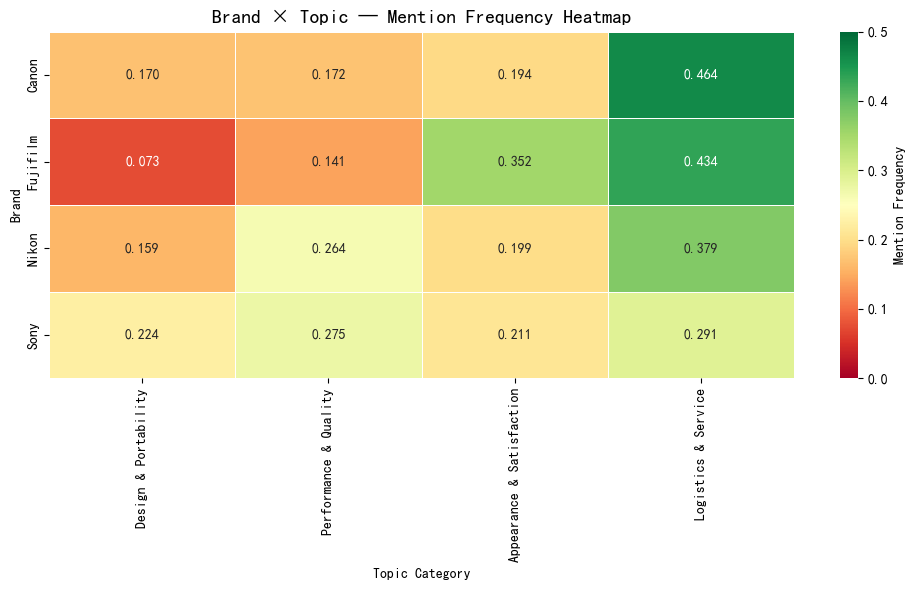

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('camera_sentiment_label.xlsx')
df = df.dropna(subset=['topic_label'])

# 数据筛选使用中文品牌名
brands_cn = ['佳能', '富士', '尼康', '索尼']
df = df[df['品牌'].isin(brands_cn)]

topic_order = ['Design & Portability', 'Performance & Quality', 'Appearance & Satisfaction', 'Logistics & Service']
df['topic_label'] = pd.Categorical(df['topic_label'], categories=topic_order, ordered=True)

# 计算提及频率
brand_total = df.groupby('品牌').size()
mention_count = df.groupby(['品牌', 'topic_label']).size().unstack(fill_value=0)
mention_freq = mention_count.div(brand_total, axis=0)

mention_freq = mention_freq.reindex(brands_cn)
mention_freq = mention_freq[topic_order]

# 将索引（品牌）从中文改为英文用于显示
brands_en = ['Canon', 'Fujifilm', 'Nikon', 'Sony']
mention_freq.index = brands_en

# 绘图
plt.figure(figsize=(10, 6))
sns.heatmap(mention_freq, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=0.5, linewidths=0.5, cbar_kws={'label': 'Mention Frequency'})
plt.title('Brand × Topic — Mention Frequency Heatmap', fontsize=14)
plt.xlabel('Topic Category')
plt.ylabel('Brand')
plt.tight_layout()
plt.savefig('heatmap_mention_frequency_by_topic.png', dpi=300)
plt.show()

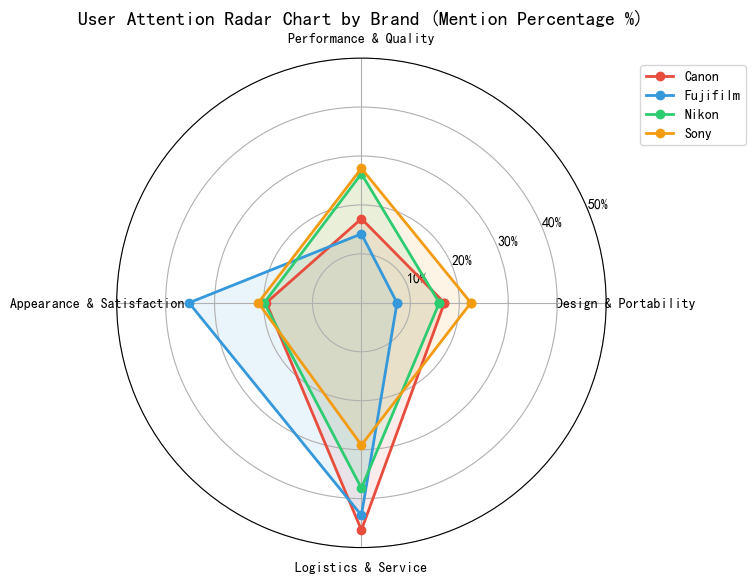

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('camera_sentiment_label.xlsx')
df = df.dropna(subset=['topic_label'])

# 数据筛选使用中文品牌名
brands_cn = ['佳能', '富士', '尼康', '索尼']
df = df[df['品牌'].isin(brands_cn)]

topic_order = ['Design & Portability', 'Performance & Quality', 'Appearance & Satisfaction', 'Logistics & Service']
df['topic_label'] = pd.Categorical(df['topic_label'], categories=topic_order, ordered=True)

# 计算提及比例（百分比）
brand_total = df.groupby('品牌').size()
mention_count = df.groupby(['品牌', 'topic_label']).size().unstack(fill_value=0)
mention_pct = (mention_count.div(brand_total, axis=0) * 100).reindex(brands_cn)
mention_pct = mention_pct[topic_order]

# 将索引（品牌）从中文改为英文用于显示
brands_en = ['Canon', 'Fujifilm', 'Nikon', 'Sony']
mention_pct.index = brands_en

# 雷达图
angles = np.linspace(0, 2 * np.pi, len(topic_order), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i, brand in enumerate(brands_en):
    values = mention_pct.loc[brand].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=brand)
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(topic_order, fontsize=10)
ax.set_ylim(0, 50)
ax.set_yticks([10, 20, 30, 40, 50])
ax.set_yticklabels(['10%', '20%', '30%', '40%', '50%'])
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.title('User Attention Radar Chart by Brand (Mention Percentage %)', fontsize=14)
plt.tight_layout()
plt.savefig('radar_chart_mention_percentage.png', dpi=300)
plt.show()

以上两图结论：
除去共同关注维度最高的售后，各品牌用户的第二关注点呈现出明显分化：
从数据看，佳能和富士的用户更关注外观（19.4% / 35.2%），而尼康和索尼的用户更关注性能（26.4% / 27.5%）。
这说明不同品牌的用户关注点略有差异：佳能和富士偏向外观，尼康和索尼偏向性能。

Conclusions from the above two charts:

Excluding after-sales logistics, which is the most mentioned dimension shared by all brands, the second most concerning dimension for users of each brand shows clear divergence:

Based on the data, users of Canon and Fujifilm pay more attention to appearance (19.4% / 35.2%), while users of Nikon and Sony focus more on performance (26.4% / 27.5%).

This indicates that user concerns vary slightly across different brands: Canon and Fujifilm users lean toward appearance, whereas Nikon and Sony users lean toward performance.

四象限图
四象限图是一种战略分析工具，以“提及频率”为横轴、“满意度”为纵轴，将不同话题划分为四个区域：
右上角是“优势区”（高提及+高满意），代表品牌核心优势，需继续保持；
右下角是“痛点区”（高提及+低满意），是最需要优先改进的短板；
左上角是“高优区”（低提及+高满意），是潜在卖点，应加强宣传；
左下角是“机会区”（低提及+低满意），可暂时搁置。

痛点区优先改，优势区保持住，高优区多宣传，机会区先不管

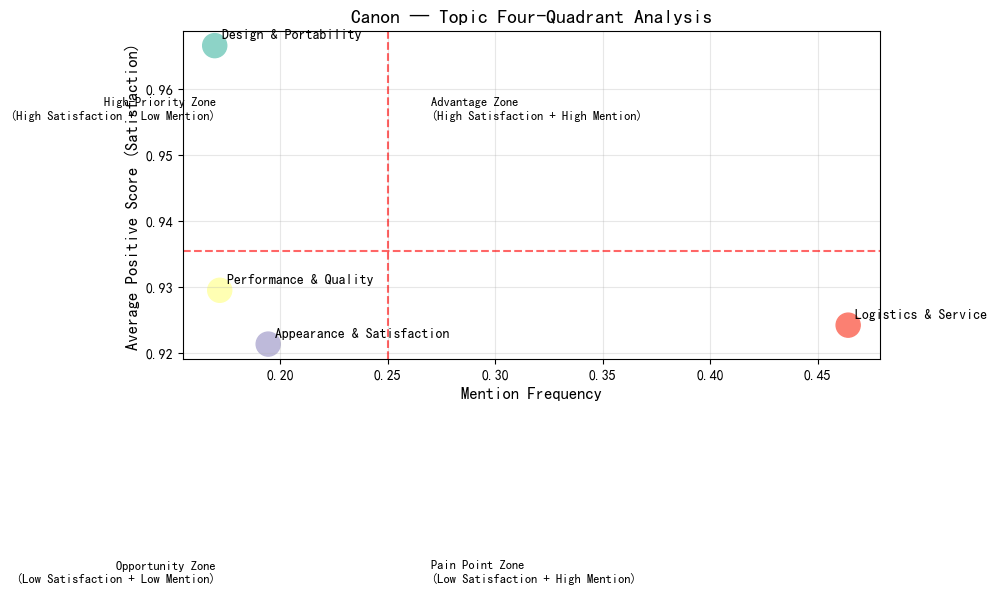


=== Canon Topic Data Table ===
                           Mention Frequency  Satisfaction Score
topic_label                                                     
Logistics & Service                 0.464230            0.924231
Appearance & Satisfaction           0.194401            0.921366
Performance & Quality               0.171851            0.929502
Design & Portability                0.169518            0.966494


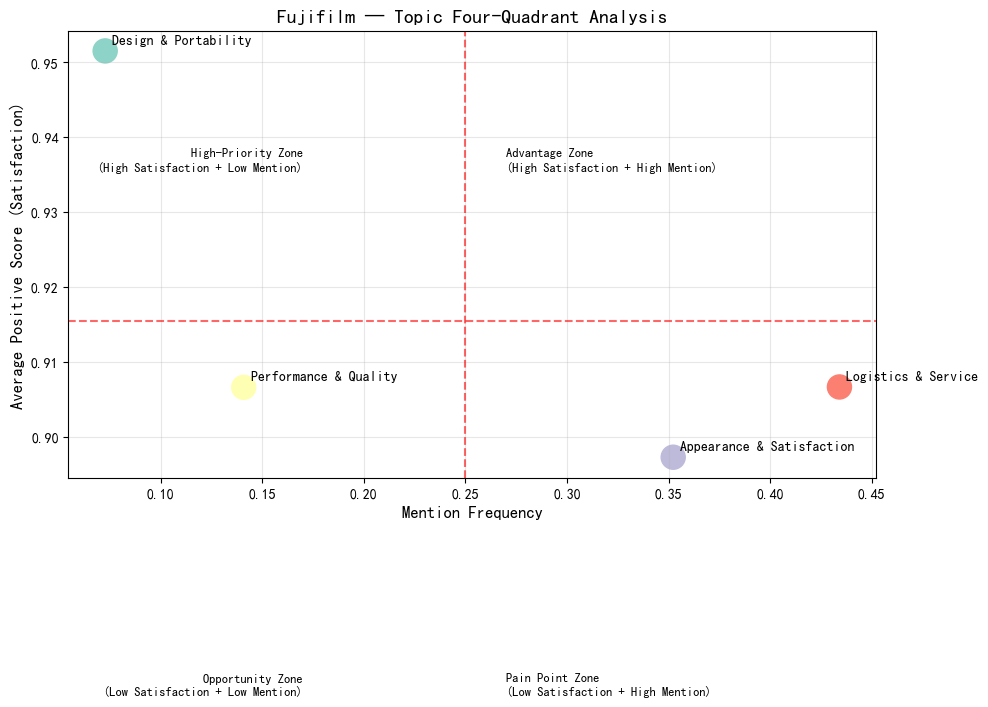


=== Fujifilm Topic Data Table ===
                           Mention Frequency  Satisfaction Score
topic_label                                                     
Logistics & Service                 0.434091            0.906641
Appearance & Satisfaction           0.352273            0.897258
Performance & Quality               0.140909            0.906589
Design & Portability                0.072727            0.951520


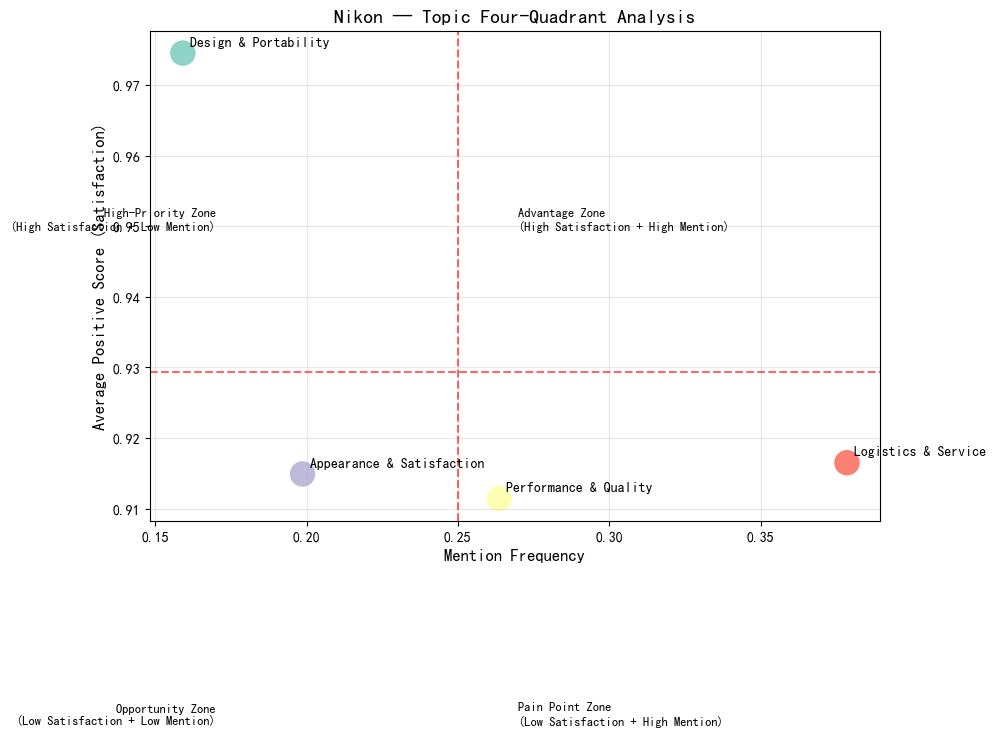


=== Nikon Topic Data Table ===
                           Mention Frequency  Satisfaction Score
topic_label                                                     
Logistics & Service                 0.378531            0.916499
Performance & Quality               0.263653            0.911418
Appearance & Satisfaction           0.198682            0.914903
Design & Portability                0.159134            0.974536


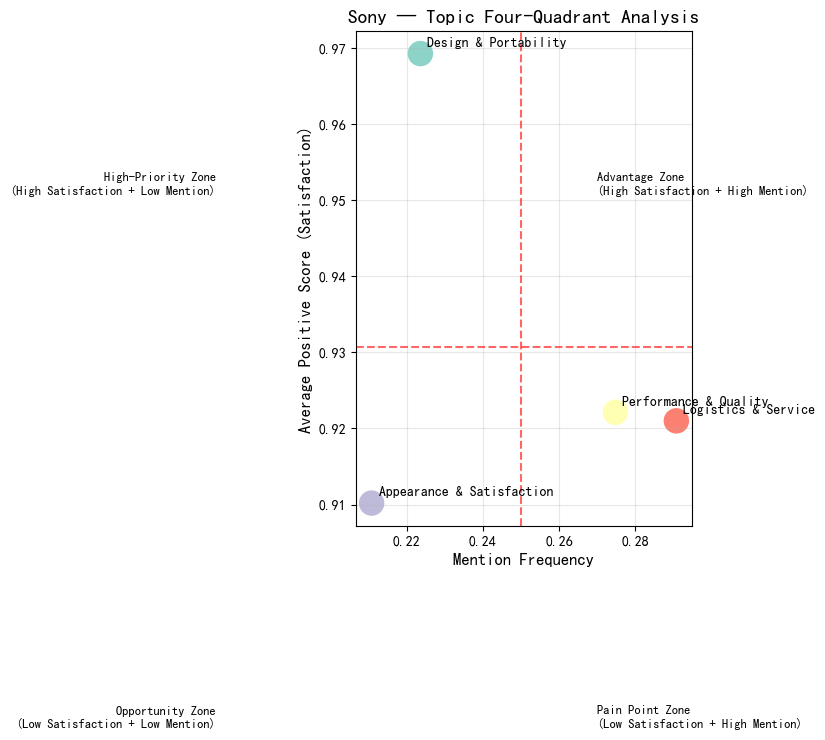


=== Sony Topic Data Table ===
                           Mention Frequency  Satisfaction Score
topic_label                                                     
Logistics & Service                 0.290735            0.921003
Performance & Quality               0.274760            0.922132
Design & Portability                0.223642            0.969259
Appearance & Satisfaction           0.210863            0.910199


In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel('camera_sentiment_label.xlsx')
df = df.dropna(subset=['topic_label'])

# 数据筛选使用中文品牌名
brands_cn = ['佳能', '富士', '尼康', '索尼']
df = df[df['品牌'].isin(brands_cn)]

topic_order = ['Design & Portability', 'Performance & Quality', 'Appearance & Satisfaction', 'Logistics & Service']
df['topic_label'] = pd.Categorical(df['topic_label'], categories=topic_order, ordered=True)

# 品牌名中英文映射
brands_en = ['Canon', 'Fujifilm', 'Nikon', 'Sony']
brand_map = dict(zip(brands_cn, brands_en))

# 为每个品牌单独画图
for brand_cn in brands_cn:
    brand_df = df[df['品牌'] == brand_cn]
    brand_en = brand_map[brand_cn]
    
    # 计算该品牌的提及频率和满意度
    total_comments = len(brand_df)
    mention_count = brand_df.groupby('topic_label').size()
    mention_freq = mention_count / total_comments
    
    satisfaction = brand_df.groupby('topic_label')['positive_score'].mean()
    
    quadrant_df = pd.DataFrame({
        'Mention Frequency': mention_freq,
        'Satisfaction Score': satisfaction
    })
    
    # 绘图
    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set3(range(len(quadrant_df)))
    plt.scatter(quadrant_df['Mention Frequency'], quadrant_df['Satisfaction Score'], s=300, c=colors)
    
    for topic in quadrant_df.index:
        plt.annotate(topic, 
                     (quadrant_df.loc[topic, 'Mention Frequency'], 
                      quadrant_df.loc[topic, 'Satisfaction Score']),
                     xytext=(5, 5), textcoords='offset points', fontsize=10)
    
    # 添加平均线
    x_mean = quadrant_df['Mention Frequency'].mean()
    y_mean = quadrant_df['Satisfaction Score'].mean()
    plt.axhline(y=y_mean, color='red', linestyle='--', alpha=0.6)
    plt.axvline(x=x_mean, color='red', linestyle='--', alpha=0.6)
    
    # 标注象限（英文）
    plt.text(x_mean + 0.02, y_mean + 0.02, 'Advantage Zone\n(High Satisfaction + High Mention)', fontsize=9, ha='left')
    plt.text(x_mean - 0.08, y_mean + 0.02, 'High-Priority Zone\n(High Satisfaction + Low Mention)', fontsize=9, ha='right')
    plt.text(x_mean + 0.02, y_mean - 0.05, 'Pain Point Zone\n(Low Satisfaction + High Mention)', fontsize=9, ha='left')
    plt.text(x_mean - 0.08, y_mean - 0.05, 'Opportunity Zone\n(Low Satisfaction + Low Mention)', fontsize=9, ha='right')
    
    plt.xlabel('Mention Frequency', fontsize=12)
    plt.ylabel('Average Positive Score (Satisfaction)', fontsize=12)
    plt.title(f'{brand_en} — Topic Four-Quadrant Analysis', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'four_quadrant_{brand_en}_by_topic.png', dpi=300)
    plt.show()
    
    print(f"\n=== {brand_en} Topic Data Table ===")
    print(quadrant_df.sort_values('Mention Frequency', ascending=False))

佳能：
佳能仅有一个痛点区：售后物流。该维度提及频率最高（46.42%），但满意度仅为0.92，处于及格线水平，未达到高分区间，需优先改进。高优区为设计便携性，满意度0.97，但提及频率仅17%，用户感知度低，建议加强宣传。性能质量和外观满意度均处于机会区，提及频率低于20%、满意度低于0.93，暂缓投入。

富士：
富士存在两个痛点区：售后物流和外观满意度。售后物流提及频率43%、满意度0.91；外观满意度提及频率35%、满意度0.90。两个维度均为高提及、低满意，需优先改进。高优区为设计便携性，满意度0.95，但提及频率仅7%，宣传潜力较大。性能质量处于机会区，双低暂缓。

尼康：
尼康存在两个痛点区：售后物流和性能质量。售后物流提及频率38%、满意度0.92；性能质量提及频率26%、满意度0.91。两个维度均为用户关注度高但满意度偏低，需优先改进。高优区为设计便携性，满意度0.97，但提及频率仅16%，建议加大宣传。外观满意度处于机会区，双低暂缓。

索尼：
索尼与尼康类似，存在两个痛点区：售后物流和性能质量。售后物流提及频率29%、满意度0.92；性能质量提及频率27%、满意度0.92。两个维度均为高提及、低满意，需优先改进。高优区为设计便携性，满意度0.97，但提及频率仅22%，可加强宣传。外观满意度处于机会区，双低暂缓

Fujifilm:

Fujifilm has two pain point zones: after-sales logistics and appearance & satisfaction. After-sales logistics has a mention frequency of 43% and a satisfaction score of 0.91; appearance & satisfaction has a mention frequency of 35% and a satisfaction score of 0.90. Both dimensions show high mention and low satisfaction, requiring priority improvement. The high-priority zone is design & portability, with a satisfaction score of 0.95 but a mention frequency of only 7%, indicating strong promotional potential. Performance & quality falls into the opportunity zone, with both metrics low, so investment can be postponed for now.

Nikon:

Nikon has two pain point zones: after-sales logistics and performance & quality. After-sales logistics has a mention frequency of 38% and a satisfaction score of 0.92; performance & quality has a mention frequency of 26% and a satisfaction score of 0.91. Both dimensions show high user attention but relatively low satisfaction, requiring priority improvement. The high-priority zone is design & portability, with a satisfaction score of 0.97 but a mention frequency of only 16%. Increased promotion is recommended. Appearance & satisfaction falls into the opportunity zone, with both metrics low, so investment can be postponed for now.

Sony:

Sony is similar to Nikon, with two pain point zones: after-sales logistics and performance & quality. After-sales logistics has a mention frequency of 29% and a satisfaction score of 0.92; performance & quality has a mention frequency of 27% and a satisfaction score of 0.92. Both dimensions show high mention and low satisfaction, requiring priority improvement. The high-priority zone is design & portability, with a satisfaction score of 0.97 but a mention frequency of only 22%. Promotion can be strengthened. Appearance & satisfaction falls into the opportunity zone, with both metrics low, so investment can be postponed for now.